In [2]:
import pandas as pd
import copy
import time
import statistics
import matplotlib.pyplot as plt
import os
import numpy as np
from sklearn.cluster import KMeans


C:\Users\25232\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\25232\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [5]:
df = pd.read_csv('client_0.csv')
df

,0,1,2,3,4,5,6,7,8,9
0,43.217,38.975,0,0,42.290,0,0,149.801,42.241,0
1,59.729,57.738,0,0,64.506,0,0,201.421,63.790,0
2,98.037,53.649,0,0,53.649,0,0,100.308,66.600,0
3,42.699,40.468,0,0,38.930,0,0,44.688,75.481,0
4,137.700,142.848,0,0,36.545,0,0,110.439,123.827,0
5,53.560,62.723,0,0,43.458,0,0,27.582,41.022,0
6,87.677,87.677,0,0,60.282,0,0,57.495,30.916,0
7,50.870,40.173,0,0,37.586,0,0,70.918,40.307,0
8,117.075,117.101,0,0,130.047,0,0,146.442,190.828,0
9,38.504,37.125,0,0,36.424,0,0,38.939,136.818,0


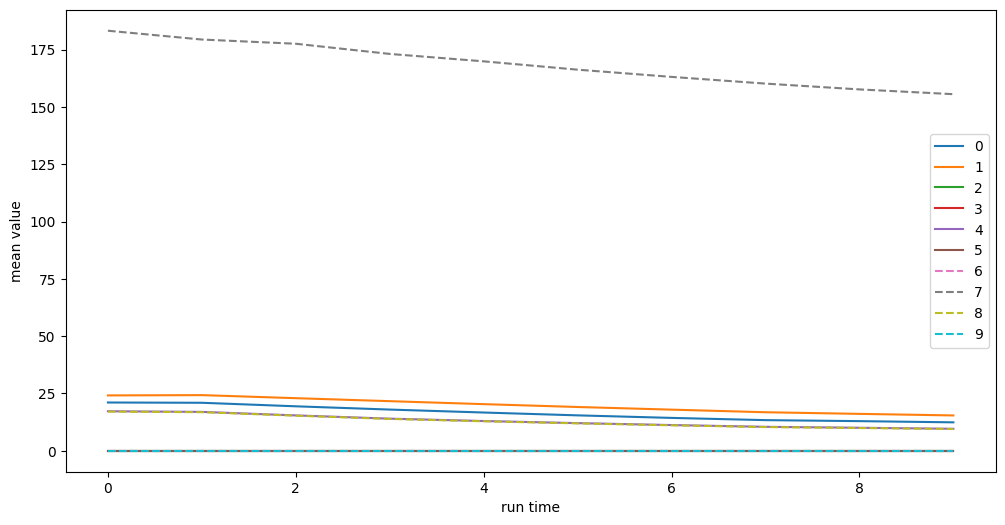

In [3]:
total_round = 15
total_run_time = 10

plt.figure(figsize=(12,6))
for column in df.columns:
    mean_list = []
    std_list = []
    for i in range(total_run_time):
        iter_data = list(df[column].iloc[i:i+total_round ])
        i += total_round 
        mean = statistics.mean(iter_data)
        std = statistics.variance(iter_data)
        mean_list.append(mean)
        std_list.append(std)
    temp = int(column.split('_')[-1])
    if temp in [6,7,8,9]:
        plt.plot(range(len(mean_list)),mean_list,label=f'{column}',ls='--')
    else:
        plt.plot(range(len(mean_list)),mean_list,label=f'{column}',ls='-')
    plt.xlabel('run time')
    plt.ylabel('mean value')
#     plt.xlim(0,total_run_time-1)

plt.legend()
plt.show()

In [4]:
num_client = 5
total_round = 15
total_run_time = 1
image_save_path = 'temp'


for j in range(num_client):
    file_path = f'client_{j}.csv'
    
    df = pd.read_csv(file_path)
    
    plt.figure(figsize=(12,6))
    for column in df.columns:
        mean_list = []
        std_list = []
        for i in range(total_run_time):
            iter_data = list(df[column].iloc[i:i+total_round ])
            i += total_round 
            mean = statistics.mean(iter_data)
            std = statistics.variance(iter_data)
            mean_list.append(mean)
            std_list.append(std)
        temp = int(column.split('_')[-1])
        if temp in [6,7,8,9]:
            plt.subplot(1,2,1)
            plt.plot(range(len(mean_list)),mean_list,label=f'{column}',ls='--')
            plt.xlabel('run time')
            plt.ylabel('mean value')
            
            plt.subplot(1,2,2)
            plt.plot(range(len(std_list)),std_list,label=f'{column}',ls='--')
            plt.xlabel('run time')
            plt.ylabel('std value')
        else:
            plt.subplot(1,2,1)
            plt.plot(range(len(mean_list)),mean_list,label=f'{column}',ls='-')
            plt.xlabel('run time')
            plt.ylabel('mean value')
            
            plt.subplot(1,2,2)
            plt.plot(range(len(std_list)),std_list,label=f'{column}',ls='-')
            plt.xlabel('run time')
            plt.ylabel('std value')
#         plt.xlabel('run time')
#         plt.ylabel('mean value')
    #     plt.xlim(0,total_run_time-1)
    plt.suptitle(f'Client {j} to others Mean and Std Analysis', fontsize=16)
    plt.legend()
    
    if not os.path.exists(image_save_path):
        os.makdirs(image_save_path)
    image_path = os.path.join(image_save_path,f"{j}.png")
    plt.savefig(image_path)
    plt.close()

In [10]:
num_client = 4
image_save_path = 'temp'

type_ = 'cos_similarity'

for j in range(num_client):
    file_path = f'cos_client_{j}.csv'
    
    df = pd.read_csv(file_path)
    
    plt.figure(figsize=(12,6))
    
    for column in df.columns:

        iter_data = list(df[column])
#         temp = int(column.split('_')[1])
        temp = int(column)
        if temp in [4,5,6,7,8,9]:
            plt.subplot(1,1,1)
            plt.plot(range(len(iter_data)),iter_data,label=f'{column}',ls='--')
            plt.xlabel('run time')
            plt.ylabel(type_)

        else:
            plt.subplot(1,1,1)
            plt.plot(range(len(iter_data)),iter_data,label=f'{column}',ls='-')
            plt.xlabel('run time')
            plt.ylabel(type_)

    plt.suptitle(f'Client {j} as the server', fontsize=16)
    plt.legend()

    if not os.path.exists(image_save_path):
        os.makdirs(image_save_path)
    image_path = os.path.join(image_save_path,f"data_{j}.png")
    plt.savefig(image_path)
    plt.close()

In [8]:
import matplotlib.pyplot as plt
# 数据列表
ASR = [0.22586111111111112, 0.257, 0.12197222222222222, 0.05325, 0.02686111111111111, 0.09111111111111111, 0.10413888888888888, 0.13261111111111112, 0.13974999999999999, 0.26125, 0.3654722222222222, 0.22252777777777777, 0.1828611111111111, 0.18288888888888888, 0.19741666666666666]


ACC = [0.5526000000000001, 0.6126250000000001, 0.6725, 0.7933, 0.8097249999999999, 0.820475, 0.8237, 0.815825, 0.8101, 0.80245, 0.80535, 0.788775, 0.8074, 0.809075, 0.821075]
image_save_path = 'temp'

plt.plot(range(len(ASR)),ASR,c='r',label='ASR')
plt.plot(range(len(ACC)),ACC,c='g',label="ACC")
plt.xlabel('Iter')
plt.ylabel("ASR & ACC")
plt.legend()
plt.savefig(os.path.join(image_save_path,f'ASR.png'))
plt.close()

In [11]:
num_client = 4
malicious_num = 6
malicious_list = ['4','5','6','7','8','9']
# malicious_list = ['6','7','8','9']
# malicious_list = ['8','9']
# 
image_save_path = 'temp'



for j in range(num_client):
    file_path = f'client_{j}.csv'
    
    df = pd.read_csv(file_path)
    x = df.columns
    
    count = {}
    plt.figure(figsize=(12,6))
    for client_num in x:
        
        count[client_num] = sum(df[client_num])/len(df[client_num])
        #g过滤掉不是邻居
        for cate in list(count.keys()):
            if cate in malicious_list:
                plt.bar(f'client_{cate}',count[cate], hatch='-')
            else:
                plt.bar(f'client_{cate}',count[cate])
        plt.xlabel('Client')
        plt.ylabel('num')
    plt.title(f'Client_{j} as the server')
    if not os.path.exists(image_save_path):
        os.makdirs(image_save_path)
    
    image_path = os.path.join(image_save_path,f"num_{j}_{malicious_num}.jpg")
    plt.savefig(image_path)
    plt.close()
    

In [3]:
num_client = 4
malicious_num = 6
malicious_list = ['4','5','6','7','8','9']
# malicious_list = ['6','7','8','9']
# malicious_list = ['8','9']
# 
image_save_path = 'temp'
import time
for j in range(num_client):
    file_path = f'cur_rcs_{j}.csv'
    
    df = pd.read_csv(file_path)
    x = df.columns
    
    count = {}
    plt.figure(figsize=(12,6))
    for client_num in x:
        weight = 1
        for index in range(len(df)):
            
            df.loc[index, client_num] = df.loc[index, client_num]* weight
#             weight -= 1
        count[client_num] = sum(df[client_num]) / len(df[client_num])
    print(count)
    for cate in list(count.keys()):
        if cate in malicious_list:
            plt.bar(f'client_{cate}',count[cate], hatch='-')
        else:
            plt.bar(f'client_{cate}',count[cate])
    plt.xlabel('Client')
    plt.ylabel('cos similarity')
    plt.title(f'Client_{j} as the server')
    if not os.path.exists(image_save_path):
        os.makdirs(image_save_path)
    
    image_path = os.path.join(image_save_path,f"num_{j}_{malicious_num}.jpg")
    plt.savefig(image_path)
    plt.close()

{'0': 0.9754666666666668, '1': 0.9754666666666668, '4': 0.1858, '7': 0.23539999999999994, '8': 0.36806666666666665}
{'0': 0.9754666666666668, '1': 0.9754666666666668, '2': 0.9363333333333334, '5': 0.2781333333333333, '9': 0.1908}
{'1': 0.9363333333333334, '2': 0.9536, '3': 0.9322666666666667, '7': 0.2426666666666667, '9': 0.20486666666666664}
{'2': 0.9322666666666667, '3': 0.9322666666666667, '4': 0.20479999999999998, '6': 0.33186666666666664, '9': 0.2185333333333333}


In [9]:
weight_matrix= np.array(
            [[1 / 5, 1 / 5, 0, 0, 1 / 5, 0, 0, 1 / 5, 1 / 5, 0],
             [1 / 5, 1 / 5, 1 / 5, 0, 0, 1 / 5, 0, 0, 0, 1 / 5],
             [0, 1 / 5, 1 / 5, 1 / 5, 0, 0, 0, 1 / 5, 0, 1 / 5],
             [0, 0, 1 / 5, 1 / 5, 1 / 5, 0, 1 / 5, 0, 0, 1 / 5],
             [1 / 5, 0, 0, 1 / 5, 1 / 5, 1 / 5, 0, 0, 0, 1 / 5],
             [0, 1 / 5, 0, 0, 1 / 5, 1 / 5, 1 / 5, 0, 1 / 5, 0],
             [0, 0, 0, 1 / 5, 0, 1 / 5, 1 / 5, 1 / 5, 1 / 5, 0],
             [1 / 5, 0, 1 / 5, 0, 0, 0, 1 / 5, 1 / 5, 1 / 5, 0],
             [1 / 5, 0, 0, 0, 0, 1 / 5, 1 / 5, 1 / 5, 1 / 5, 0],
             [0, 1 / 5, 1 / 5, 1 / 5, 1 / 5, 0, 0, 0, 0, 1 / 5],
             ])

In [10]:
# num_client = 6
# malicious_num = 4
# malicious_list = ['4','5','6','7','8','9']
# malicious_list = ['6','7','8','9']
# malicious_list = ['8','9']
# 
num_worker=10
num_attackers=6
# image_save_path = 'temp'
for j in range(num_worker-num_attackers):
    
    cur_adjs = np.where(weight_matrix[j] != 0)[0]
    
    file_path = f'cos_client_{j}.csv'
    df = pd.read_csv(file_path)
    x = df.columns
    count = {}
    for client_num in cur_adjs:
        
        if client_num == j:
            pass
        else:
            count[str(client_num)] = sum(df[str(client_num)])/len(df[str(client_num)])
    
    # 转换数据格式
    keys = list(count.keys())
    values = np.array(list(count.values())).reshape(-1, 1)

    # 手动设置聚类中心
    initial_centers = np.array([[count[str(j)]], [max(count.values())]])  # 手动设置初始中心

    # KMeans 聚类
    kmeans = KMeans(n_clusters=2, init=initial_centers, n_init=1, random_state=42)
    kmeans.fit(values)

    # 结果映射
    clusters = kmeans.labels_
    clustered_data = {key: cluster for key, cluster in zip(keys, clusters)}

    malicious = []    
    for key,type_ in clustered_data.items():
        if type_ == 1:
            malicious.append(key)
    print(f'client:{j} choise:{malicious} as malicous client')

KeyError: '0'

(tensor([[1, 2],
         [3, 4]]),
 tensor([[1, 2],
         [3, 4]]),
 tensor([[ 7, 10],
         [15, 22]]),
 tensor([[ 7, 10],
         [15, 22]]))